# 03B - Baseline CNN with Augmentation and Mild Targeted Oversampling

This experiment keeps the custom baseline CNN and on-the-fly augmentation from `03A`, then adds mild targeted oversampling on the training dataframe only.

No class weights are used. The goal is to improve minority/weak class exposure without the aggressive loss distortion observed in the full class-weight experiment.

Compare against:

- `02_baseline_cnn.ipynb`: plain baseline, accuracy about 0.7555, macro F1 about 0.7008
- `03A_baseline_cnn_augmentation_only.ipynb`: augmentation only, accuracy about 0.7502, macro F1 about 0.6984
- previous full class weights run: accuracy about 0.6776, macro F1 about 0.6347


## 1. Project setup


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(f"Could not find src/ from current directory: {NOTEBOOK_DIR}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system


## 2. Imports and configuration


In [2]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay

from src.config import (
    CLASS_NAMES_PATH,
    CM_DIR,
    FIGURES_DIR,
    IMAGE_SIZE,
    MODELS_DIR,
    NUM_CLASSES,
    RANDOM_SEED,
    GROUPED_SPLITS_DIR,
)

# Use grouped source-image splits to avoid offline-augmentation leakage.
SPLITS_DIR = GROUPED_SPLITS_DIR
from src.data.augmentations import build_training_augmentation
from src.data.dataloaders import make_dataset_from_dataframe
from src.data.prepare_dataset import targeted_oversample_dataframe
from src.models.baseline_cnn import build_baseline_cnn
from src.train.evaluate import evaluate_model
from src.train.train import compile_model, train_model

tf.keras.utils.set_random_seed(RANDOM_SEED)

EXPERIMENT_NAME = "baseline_cnn_aug_oversampled"
TARGET_MIN_COUNT = 500
EPOCHS = 12
LEARNING_RATE = 1e-3

EXPERIMENT_MODELS_DIR = MODELS_DIR / "experiments"
EXPERIMENT_MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Experiment:", EXPERIMENT_NAME)
print("Target minimum train count:", TARGET_MIN_COUNT)


I0000 00:00:1777882913.206958    7886 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777882923.405649    7886 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777882947.398671    7886 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Experiment: baseline_cnn_aug_oversampled
Target minimum train count: 500


## 3. Load split files and class names


In [3]:
train_csv = SPLITS_DIR / "train.csv"
val_csv = SPLITS_DIR / "val.csv"
test_csv = SPLITS_DIR / "test.csv"

for path in [train_csv, val_csv, test_csv, CLASS_NAMES_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}. Run 01_eda.ipynb first.")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)

class_to_index = {name: idx for idx, name in enumerate(class_names)}

for split_df in [train_df, val_df, test_df]:
    if "class_index" not in split_df.columns:
        split_df["class_index"] = split_df["class_name"].map(class_to_index)

print("Original train/val/test:", len(train_df), len(val_df), len(test_df))
print("Classes:", len(class_names))
assert len(class_names) == NUM_CLASSES


Original train/val/test: 19674 4788 4815
Classes: 28


## 4. Mild targeted oversampling

Only training rows are oversampled. Validation and test remain untouched.

Classes below `TARGET_MIN_COUNT` are sampled with replacement until they reach the target count. Larger classes are not downsampled.


In [4]:
original_counts = train_df["class_name"].value_counts().reindex(class_names)
train_oversampled_df = targeted_oversample_dataframe(
    train_df,
    target_min_count=TARGET_MIN_COUNT,
    class_column="class_name",
    random_state=RANDOM_SEED,
)

oversampled_counts = train_oversampled_df["class_name"].value_counts().reindex(class_names)
oversampling_summary = pd.DataFrame({
    "class_name": class_names,
    "original_train_count": original_counts.values,
    "oversampled_train_count": oversampled_counts.values,
})
oversampling_summary["added_rows"] = (
    oversampling_summary["oversampled_train_count"]
    - oversampling_summary["original_train_count"]
)
oversampling_summary["oversampled_ratio"] = (
    oversampling_summary["oversampled_train_count"]
    / oversampling_summary["original_train_count"]
).round(2)

display(oversampling_summary.sort_values("added_rows", ascending=False))
print("Original train rows:", len(train_df))
print("Oversampled train rows:", len(train_oversampled_df))
print("Added rows:", len(train_oversampled_df) - len(train_df))


,class_name,original_train_count,oversampled_train_count,added_rows,oversampled_ratio
21,Pomegranate__Rotten,131,500,369,3.82
14,Jujube__Healthy,132,500,368,3.79
11,Grape__Rotten,134,500,366,3.73
15,Jujube__Rotten,134,500,366,3.73
12,Guava__Healthy,134,500,366,3.73
10,Grape__Healthy,135,500,365,3.70
13,Guava__Rotten,135,500,365,3.70
20,Pomegranate__Healthy,137,500,363,3.65
7,Carrot__Rotten,390,500,110,1.28
5,Bellpepper__Rotten,390,500,110,1.28


Original train rows: 19674
Oversampled train rows: 23590
Added rows: 3916


## 5. Build TensorFlow datasets

The training dataset uses the oversampled dataframe. Validation and test use the original split dataframes.


In [5]:
train_ds = make_dataset_from_dataframe(train_oversampled_df, class_to_index, training=True)
val_ds = make_dataset_from_dataframe(val_df, class_to_index, training=False)
test_ds = make_dataset_from_dataframe(test_df, class_to_index, training=False)

for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Label batch:", labels.shape)


I0000 00:00:1777882975.532290    7886 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Image batch: (32, 224, 224, 3)
Label batch: (32,)


## 6. Build and train augmented oversampled baseline


In [6]:
checkpoint_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_best.keras"

augmentation = build_training_augmentation()
model = build_baseline_cnn(num_classes=NUM_CLASSES, augmentation=augmentation)
model = compile_model(model, learning_rate=LEARNING_RATE)
model.summary()

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=EPOCHS,
    checkpoint_path=checkpoint_path,
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,860 (378.36 KB)

 Trainable params: 96,860 (378.36 KB)

 Non-trainable params: 0 (0.00 B)

...

738/738 ━━━━━━━━━━━━━━━━━━━━ 69s 91ms/step - accuracy: 0.7311 - loss: 0.9157 - val_accuracy: 0.7625 - val_loss: 0.8261 - learning_rate: 0.0010
Epoch 12/12
386/738 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - accuracy: 0.7328 - loss: 0.8911

W0000 00:00:1777883845.157671   10655 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


675/738 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.7353 - loss: 0.8860

W0000 00:00:1777883869.232533   10670 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


738/738 ━━━━━━━━━━━━━━━━━━━━ 65s 86ms/step - accuracy: 0.7423 - loss: 0.8707 - val_accuracy: 0.7343 - val_loss: 0.8849 - learning_rate: 0.0010


## 7. Training curves


,accuracy,loss,val_accuracy,val_loss,learning_rate
7,0.690377,1.061716,0.732456,0.950220,0.001
8,0.705172,1.011157,0.717210,0.938130,0.001
9,0.721662,0.956567,0.767962,0.821511,0.001
10,0.731072,0.915691,0.762531,0.826051,0.001
11,0.742306,0.870697,0.734336,0.884929,0.001


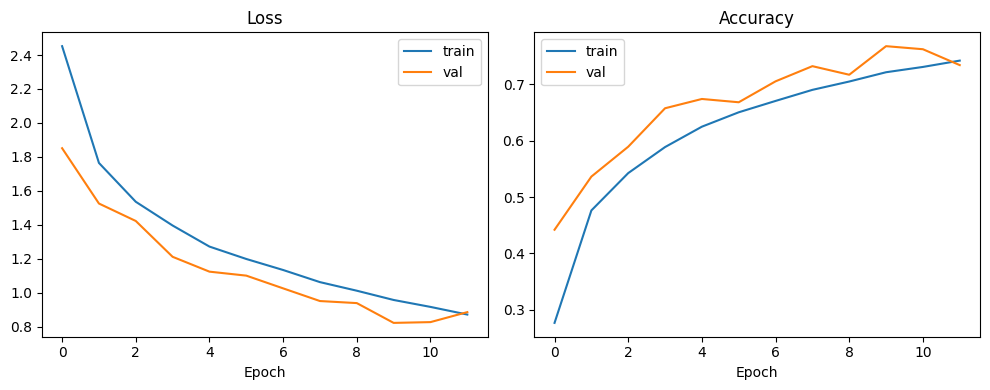

In [7]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train")
plt.plot(history_df["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train")
plt.plot(history_df["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
curves_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()


## 8. Evaluate on test set


In [8]:
results = evaluate_model(model, test_ds, class_names)
report = results["classification_report"]
cm = results["confusion_matrix"]

report_df = pd.DataFrame(report).transpose()
display(report_df)

accuracy = float(report["accuracy"])
macro_f1 = float(report["macro avg"]["f1-score"])
weighted_f1 = float(report["weighted avg"]["f1-score"])

print("Test accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))


W0000 00:00:1777883891.779115   10854 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


,precision,recall,f1-score,support
Apple__Healthy,0.806548,0.687817,0.742466,394.000000
Apple__Rotten,0.674419,0.717526,0.695305,485.000000
Banana__Healthy,0.707386,0.867596,0.779343,287.000000
Banana__Rotten,0.881633,0.894410,0.887975,483.000000
Bellpepper__Healthy,0.947368,0.529412,0.679245,102.000000
Bellpepper__Rotten,0.393443,0.240000,0.298137,100.000000
Carrot__Healthy,0.731959,0.689320,0.710000,103.000000
Carrot__Rotten,0.536842,0.536842,0.536842,95.000000
Cucumber__Healthy,0.674074,0.892157,0.767932,102.000000
Cucumber__Rotten,0.508333,0.635417,0.564815,96.000000


Test accuracy: 0.7475
Macro F1: 0.7145
Weighted F1: 0.7421


## 9. Focus on weak classes from the plain baseline


In [9]:
weak_classes_from_plain_baseline = [
    "Tomato__Rotten",
    "Bellpepper__Rotten",
    "Potato__Rotten",
    "Pomegranate__Rotten",
    "Carrot__Rotten",
]

available_weak_classes = [name for name in weak_classes_from_plain_baseline if name in report_df.index]
display(report_df.loc[available_weak_classes, ["precision", "recall", "f1-score", "support"]])


,precision,recall,f1-score,support
Tomato__Rotten,0.575758,0.197917,0.294574,96.0
Bellpepper__Rotten,0.393443,0.240000,0.298137,100.0
Potato__Rotten,0.522222,0.484536,0.502674,97.0
Pomegranate__Rotten,0.400000,0.514286,0.450000,35.0
Carrot__Rotten,0.536842,0.536842,0.536842,95.0


## 10. Optional comparison with previous experiment reports

This cell compares against saved reports if they exist locally.


In [10]:
comparison_paths = {
    "plain_baseline": FIGURES_DIR / "baseline_cnn_classification_report.csv",
    "aug_only": FIGURES_DIR / "baseline_cnn_aug_only_classification_report.csv",
}

rows = []
for name, path in comparison_paths.items():
    if path.exists():
        prev = pd.read_csv(path, index_col=0)
        rows.append({
            "experiment": name,
            "accuracy": float(prev.loc["accuracy", "precision"]),
            "macro_f1": float(prev.loc["macro avg", "f1-score"]),
            "weighted_f1": float(prev.loc["weighted avg", "f1-score"]),
        })

rows.append({
    "experiment": EXPERIMENT_NAME,
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
})

comparison_df = pd.DataFrame(rows)
display(comparison_df)


,experiment,accuracy,macro_f1,weighted_f1
0,plain_baseline,0.730218,0.673706,0.721436
1,aug_only,0.750363,0.685190,0.739227
2,baseline_cnn_aug_oversampled,0.747456,0.714520,0.742133


## 11. Confusion matrix


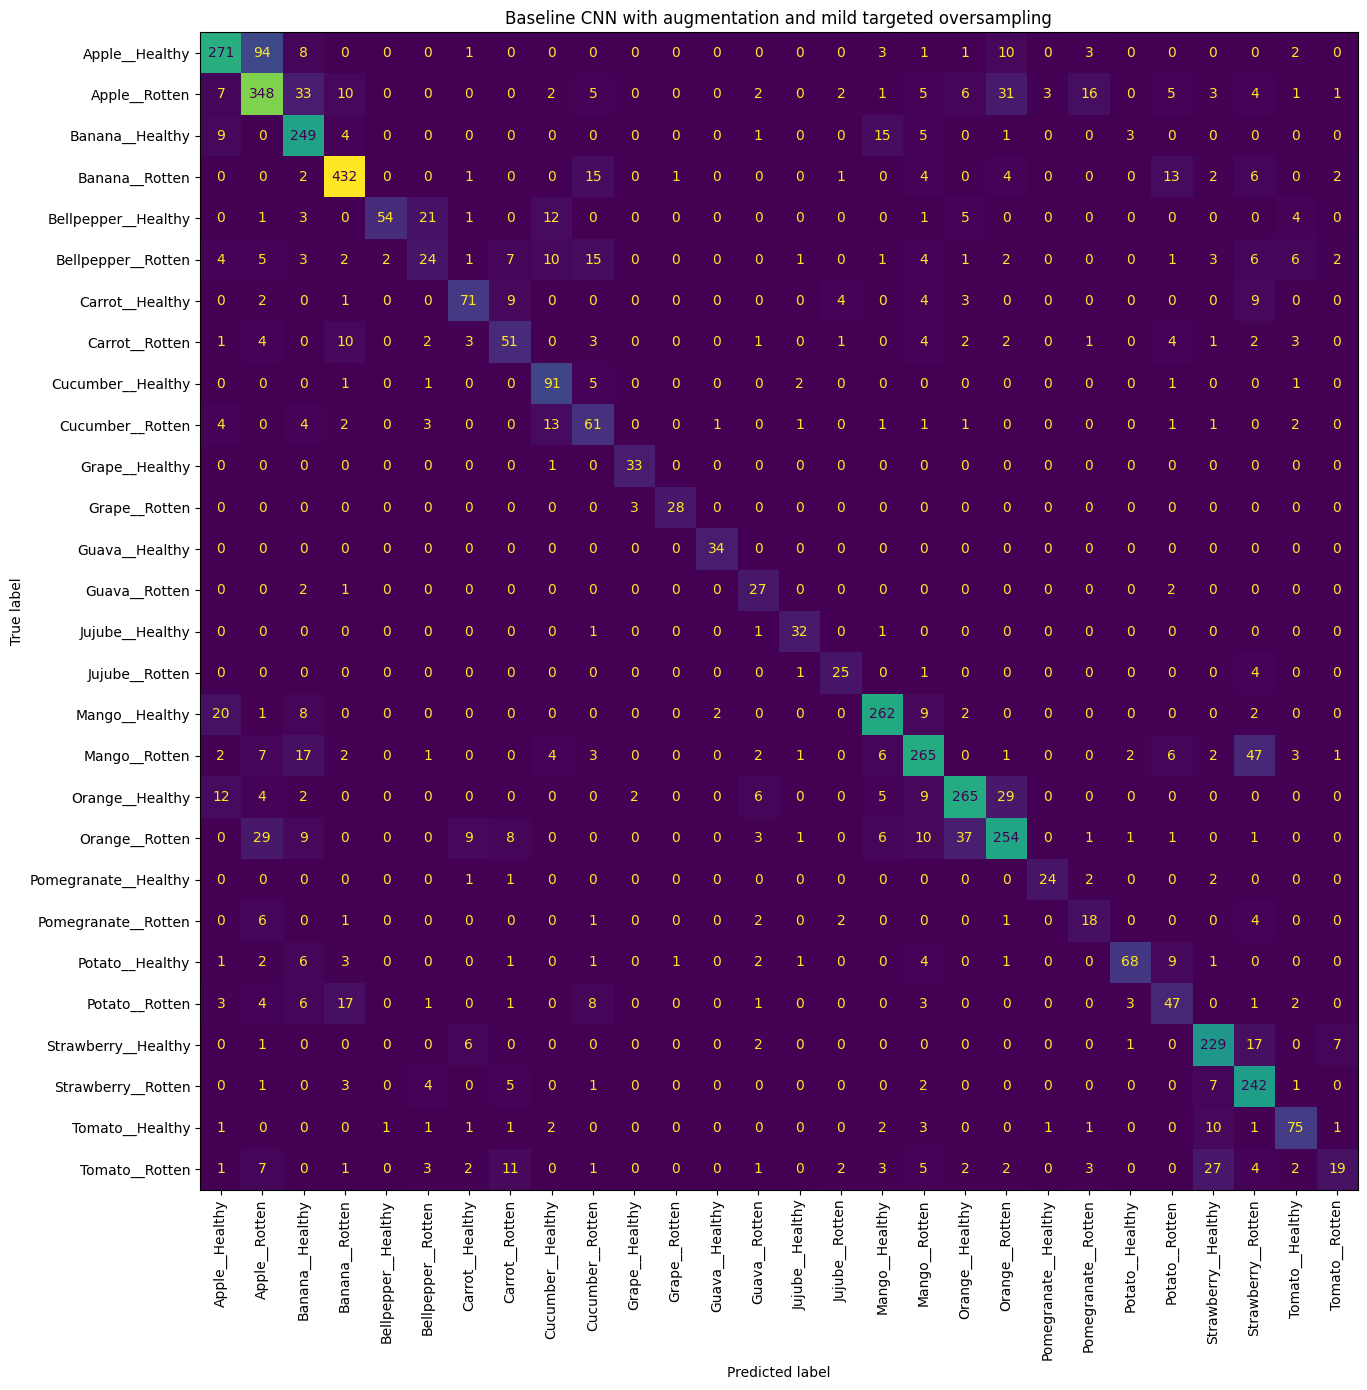

In [11]:
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Baseline CNN with augmentation and mild targeted oversampling")
plt.tight_layout()
cm_path = CM_DIR / f"{EXPERIMENT_NAME}_confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()


## 12. Save experiment artifacts

This notebook does not overwrite `models/best_model.keras`. That file should only be updated after comparing all candidate models.


In [12]:
model_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}.keras"
metadata_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_metadata.json"
report_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_classification_report.csv"
oversampling_summary_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_oversampling_summary.csv"

model.save(model_path)
report_df.to_csv(report_path)
oversampling_summary.to_csv(oversampling_summary_path, index=False)

metadata = {
    "model_name": EXPERIMENT_NAME,
    "base_model_family": "custom_baseline_cnn",
    "dataset": "muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten",
    "num_classes": NUM_CLASSES,
    "image_size": list(IMAGE_SIZE),
    "epochs_requested": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "augmentation": True,
    "class_weighting": None,
    "oversampling": {
        "enabled": True,
        "strategy": "targeted_min_count_with_replacement",
        "target_min_count": TARGET_MIN_COUNT,
        "original_train_rows": int(len(train_df)),
        "oversampled_train_rows": int(len(train_oversampled_df)),
    },
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "metrics": {
        "test_accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    },
    "artifacts": {
        "model": str(model_path),
        "checkpoint": str(checkpoint_path),
        "metadata": str(metadata_path),
        "classification_report": str(report_path),
        "oversampling_summary": str(oversampling_summary_path),
        "training_curves": str(curves_path),
        "confusion_matrix": str(cm_path),
    },
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved experiment model:", model_path)
print("Saved checkpoint:", checkpoint_path)
print("Saved metadata:", metadata_path)
print("Saved oversampling summary:", oversampling_summary_path)
print("Did not overwrite models/best_model.keras")


Saved experiment model: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/baseline_cnn_aug_oversampled.keras
Saved checkpoint: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/baseline_cnn_aug_oversampled_best.keras
Saved metadata: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/baseline_cnn_aug_oversampled_metadata.json
Saved oversampling summary: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/baseline_cnn_aug_oversampled_oversampling_summary.csv
Did not overwrite models/best_model.keras


## 13. Decision rule

This experiment is useful if it improves macro F1 or weak rotten-class F1 without a large accuracy drop.

If it improves the weak classes but still does not beat the plain baseline overall, keep the result as evidence that custom CNN capacity is the limiting factor and move to MobileNetV2 transfer learning.
